# 02 - Eksperimen Baseline & Model Gabungan
Hasil dibuat oleh `src/run_experiments.py` (disimpan di `results/metrics.csv`).

**Model yang dibandingkan**
- Baseline: `majority`, `persistence` (naive), `arima`, `xgb:kurs` (XGBoost, fitur kurs saja)
- Model gabungan: XGBoost dengan fitur kurs + lexicon, kurs + TF-IDF, dan kurs + lexicon + TF-IDF

**Protokol**: model dilatih di train; data validasi dipakai memilih hyperparameter; data test dipakai satu kali untuk skor akhir.

In [1]:
import sys; sys.path.append('../src')
import pandas as pd, matplotlib.pyplot as plt
from config import ROOT
from evaluate import cm_table
m = pd.read_csv(ROOT / 'results/metrics.csv')
p = pd.read_csv(ROOT / 'results/predictions_test.csv')
cols = ['model', 'DA', 'F1_macro', 'share_pred1']
print('VALIDASI'); print(m[m.split == 'val'][cols].round(3).to_string(index=False))
print('\nTEST');     print(m[m.split == 'test'][cols].round(3).to_string(index=False))

VALIDASI
                          model    DA  F1_macro  share_pred1
                       majority 0.512     0.339        1.000
                    persistence 0.542     0.541        0.512
                          arima 0.542     0.537        0.588
                       xgb:kurs 0.525     0.459        0.838
               xgb:kurs+lexicon 0.554     0.523        0.742
                 xgb:kurs+tfidf 0.521     0.513        0.617
              xgb:kurs+category 0.533     0.533        0.512
xgb:kurs+lexicon+tfidf+category 0.542     0.533        0.621

TEST
                          model    DA  F1_macro  share_pred1
                       majority 0.573     0.364        1.000
                    persistence 0.531     0.520        0.577
                          arima 0.544     0.518        0.656
                       xgb:kurs 0.519     0.457        0.763
               xgb:kurs+lexicon 0.568     0.527        0.722
                 xgb:kurs+tfidf 0.502     0.494        0.556
         

`share_pred1` = proporsi hari yang diprediksi "rupiah melemah". Kalau nilainya mendekati 1, model hampir selalu menebak kelas 1. Dalam kasus itu DA-nya mirip majority baseline dan F1 macro-nya rendah, jadi DA harus dibaca bersama F1 macro.

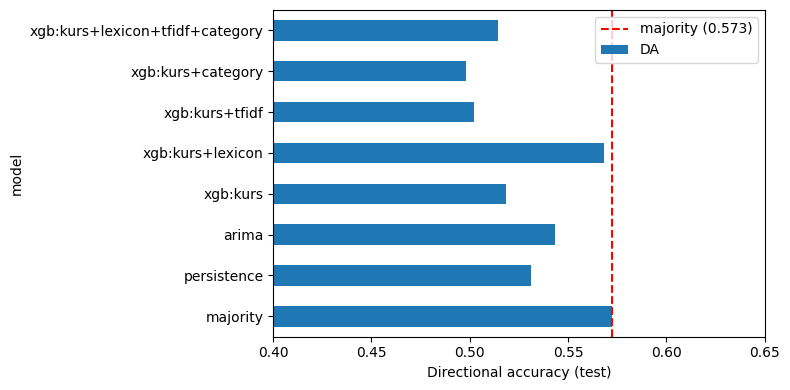

In [2]:
# Perbandingan Directional Accuracy di data test
t = m[m.split == 'test'].set_index('model')['DA']
maj = t['majority']
ax = t.plot.barh(figsize=(8, 4))
ax.axvline(maj, color='r', ls='--', label=f'majority ({maj:.3f})')
ax.set_xlim(0.4, 0.65); ax.set_xlabel('Directional accuracy (test)'); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# Confusion matrix di data test
for name in ['majority', 'xgb:kurs', 'xgb:kurs+lexicon', 'xgb:kurs+tfidf', 'xgb:kurs+category', 'xgb:kurs+lexicon+tfidf+category']:
    print(name); print(cm_table(p['y'], p[name]).to_string(), '\n')


majority
                          pred_0  pred_1
aktual_0 (tidak melemah)       0     103
aktual_1 (melemah)             0     138 

xgb:kurs
                          pred_0  pred_1
aktual_0 (tidak melemah)      22      81
aktual_1 (melemah)            35     103 

xgb:kurs+lexicon
                          pred_0  pred_1
aktual_0 (tidak melemah)      33      70
aktual_1 (melemah)            34     104 

xgb:kurs+tfidf
                          pred_0  pred_1
aktual_0 (tidak melemah)      45      58
aktual_1 (melemah)            62      76 

xgb:kurs+category
                          pred_0  pred_1
aktual_0 (tidak melemah)      42      61
aktual_1 (melemah)            60      78 

xgb:kurs+lexicon+tfidf+category
                          pred_0  pred_1
aktual_0 (tidak melemah)      36      67
aktual_1 (melemah)            50      88 



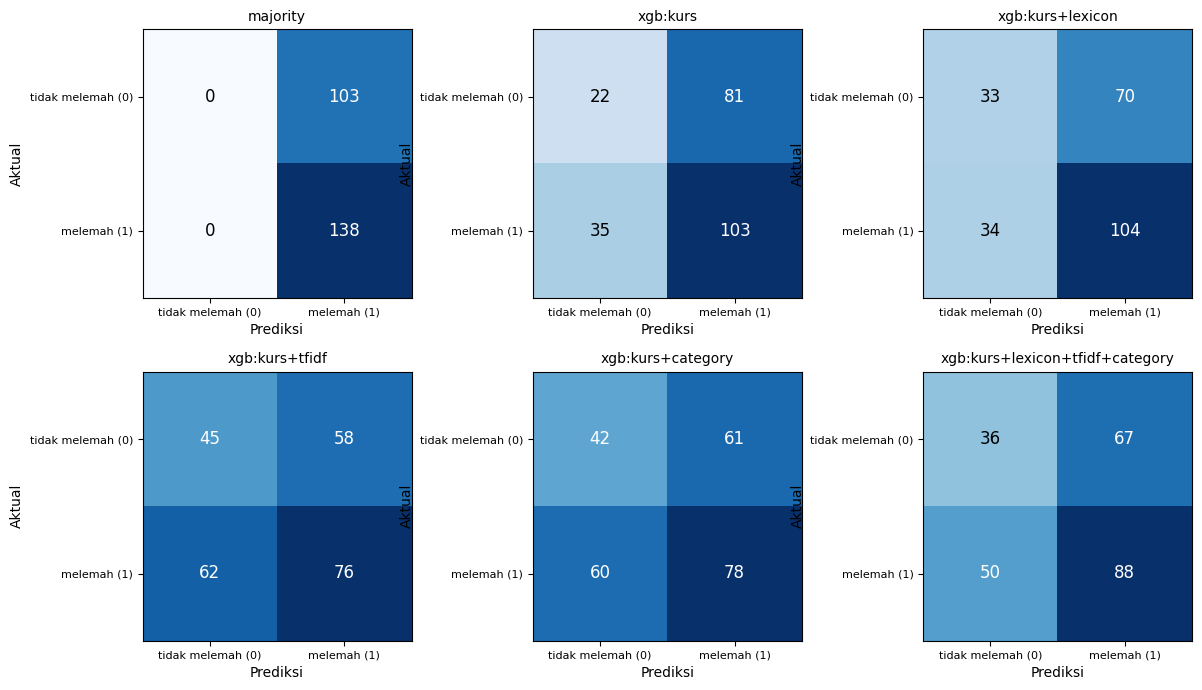

In [7]:
from sklearn.metrics import confusion_matrix

models_to_plot = ['majority', 'xgb:kurs', 'xgb:kurs+lexicon', 'xgb:kurs+tfidf',
                  'xgb:kurs+category', 'xgb:kurs+lexicon+tfidf+category']
labels = ['tidak melemah (0)', 'melemah (1)']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, name in zip(axes.flat, models_to_plot):
    cm = confusion_matrix(p['y'], p[name], labels=[0, 1])
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()